In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [73]:
customers = pd.read_csv("olist_customers_dataset.csv")
orders = pd.read_csv("olist_orders_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
order_items = pd.read_csv("olist_order_items_dataset.csv")
category_translation = pd.read_csv("product_category_name_translation.csv")

In [77]:
customers.shape
orders.shape
payments.shape
products.shape
order_items.shape

(112650, 7)

In [9]:
customers.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [10]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [11]:
products.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [12]:
order_items.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [13]:
payments.isnull().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

In [14]:
customers.duplicated().sum()

np.int64(0)

In [15]:
orders.duplicated().sum()

np.int64(0)

In [11]:
payments.duplicated().sum()

np.int64(0)

In [16]:
products.duplicated().sum()

np.int64(0)

In [17]:
order_items.duplicated().sum()

np.int64(0)

In [19]:
products['product_category_name'].fillna(
    'Unknown',
    inplace=True
)

In [20]:
products.fillna(
    products.median(numeric_only=True),
    inplace=True
)

In [21]:
products.isnull().sum()

product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64

In [23]:
orders['order_approved_at'].fillna(
    'Unknown',
    inplace=True
)

In [24]:
orders.fillna(
    orders.median(numeric_only=True),
    inplace=True
)

In [26]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                   0
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [28]:
orders['order_delivered_carrier_date'].fillna(
    'Unknown',
    inplace=True
)

In [30]:
orders['order_delivered_customer_date'].fillna(
    'Unknown',
    inplace=True
)

In [31]:
orders.isnull().sum()

order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
dtype: int64

In [32]:
print(customers.shape)
print(orders.shape)
print(payments.shape)
print(products.shape)
print(order_items.shape)

(99441, 5)
(99441, 8)
(103886, 5)
(32951, 9)
(112650, 7)


In [33]:
df = orders.merge(
    payments,
    on='order_id',
    how='left'
)

In [34]:
df = df.merge(
    customers,
    on='customer_id',
    how='left'
)

In [35]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,credit_card,1.0,18.12,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,3.0,voucher,1.0,2.00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2.0,voucher,1.0,18.59,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,boleto,1.0,141.46,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1.0,credit_card,3.0,179.12,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO


In [36]:
df.tail()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
103882,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00,1.0,credit_card,3.0,85.08,6359f309b166b0196dbf7ad2ac62bb5a,12209,sao jose dos campos,SP
103883,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00,1.0,credit_card,3.0,195.00,da62f9e57a76d978d02ab5362c509660,11722,praia grande,SP
103884,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00,1.0,credit_card,5.0,271.01,737520a9aad80b3fbbdad19b66b37b30,45920,nova vicosa,BA
103885,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,1.0,credit_card,4.0,441.16,5097a5312c8b157bb7be58ae360ef43c,28685,japuiba,RJ
103886,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-03-08 20:57:30,2018-03-09 11:20:28,2018-03-09 22:11:59,2018-03-16 13:08:30,2018-04-03 00:00:00,1.0,debit_card,1.0,86.86,60350aa974b26ff12caad89e55993bd6,83750,lapa,PR


In [37]:
df.shape

(103887, 16)

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103887 entries, 0 to 103886
Data columns (total 16 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       103887 non-null  object 
 1   customer_id                    103887 non-null  object 
 2   order_status                   103887 non-null  object 
 3   order_purchase_timestamp       103887 non-null  object 
 4   order_approved_at              103887 non-null  object 
 5   order_delivered_carrier_date   103887 non-null  object 
 6   order_delivered_customer_date  103887 non-null  object 
 7   order_estimated_delivery_date  103887 non-null  object 
 8   payment_sequential             103886 non-null  float64
 9   payment_type                   103886 non-null  object 
 10  payment_installments           103886 non-null  float64
 11  payment_value                  103886 non-null  float64
 12  customer_unique_id            

In [39]:
df.describe()

,payment_sequential,payment_installments,payment_value,customer_zip_code_prefix
count,103886.000000,103886.000000,103886.000000,103887.000000
mean,1.092679,2.853349,154.100380,35072.353490
std,0.706584,2.687051,217.494064,29743.416343
min,1.000000,0.000000,0.000000,1003.000000
25%,1.000000,1.000000,56.790000,11367.500000
50%,1.000000,1.000000,100.000000,24360.000000
75%,1.000000,4.000000,171.837500,58418.000000
max,29.000000,24.000000,13664.080000,99990.000000


In [40]:
## Total Revenue

df['payment_value'].sum()

np.float64(16008872.12)

In [41]:
## Revenue by State

state_revenue=(
    df.groupby('customer_state')['payment_value'].sum().sort_values(ascending = False)
)
state_revenue.head(10)

customer_state
SP    5998226.96
RJ    2144379.69
MG    1872257.26
RS     890898.54
PR     811156.38
SC     623086.43
BA     616645.82
DF     355141.08
GO     350092.31
ES     325967.55
Name: payment_value, dtype: float64

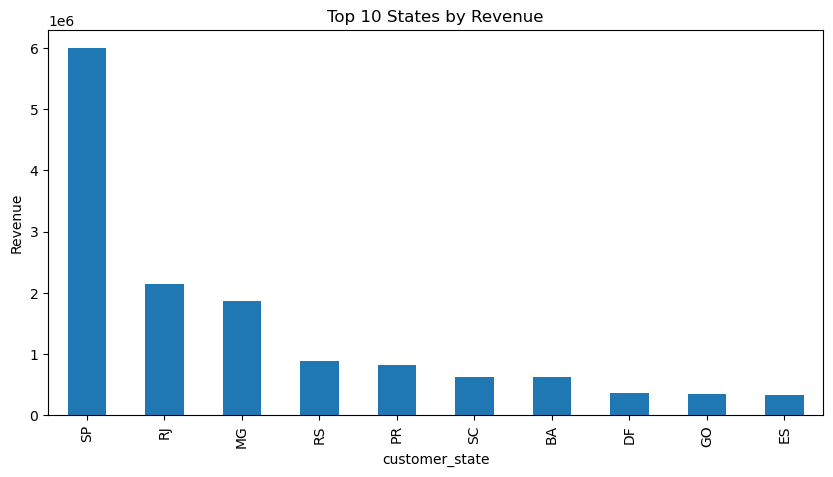

In [42]:
state_revenue.head(10).plot(
    kind = 'bar',
    figsize = (10,5)
)
plt.title('Top 10 States by Revenue')
plt.ylabel('Revenue')
plt.show()

In [43]:
## Top 10 Customers by Revenue

top_customers = (
    df.groupby('customer_unique_id')['payment_value'].sum().sort_values(ascending = False)
)
top_customers.head(10)

customer_unique_id
0a0a92112bd4c708ca5fde585afaa872    13664.08
46450c74a0d8c5ca9395da1daac6c120     9553.02
da122df9eeddfedc1dc1f5349a1a690c     7571.63
763c8b1c9c68a0229c42c9fc6f662b93     7274.88
dc4802a71eae9be1dd28f5d788ceb526     6929.31
459bef486812aa25204be022145caa62     6922.21
ff4159b92c40ebe40454e3e6a7c35ed6     6726.66
4007669dec559734d6f53e029e360987     6081.54
5d0a2980b292d049061542014e8960bf     4809.44
eebb5dda148d3893cdaf5b5ca3040ccb     4764.34
Name: payment_value, dtype: float64

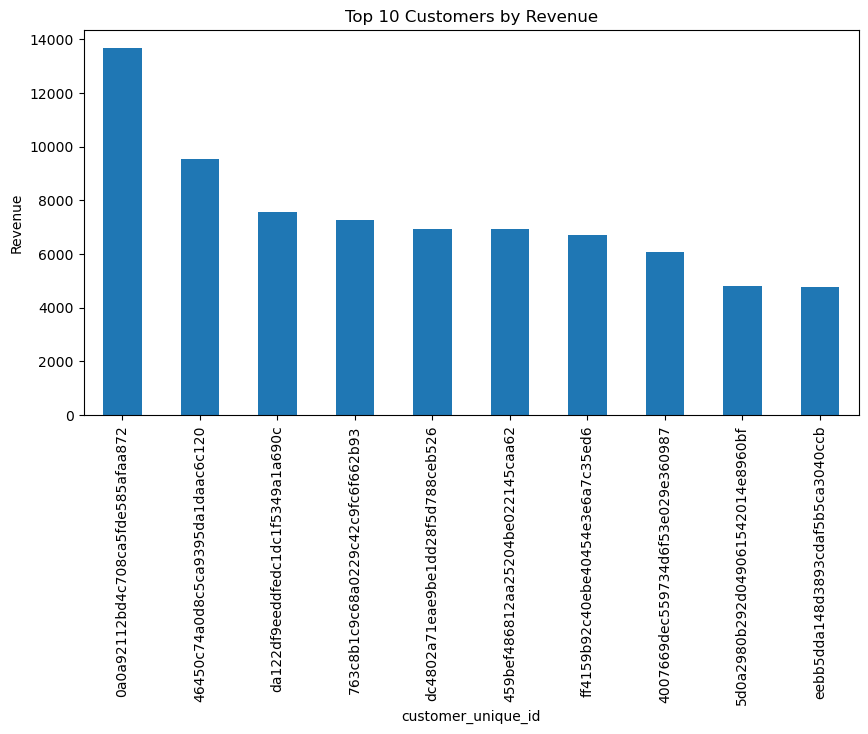

In [44]:
## Visualization

top_customers.head(10).plot(
    kind = 'bar',
    figsize = (10,5)
)
plt.title('Top 10 Customers by Revenue')
plt.ylabel('Revenue')
plt.show()


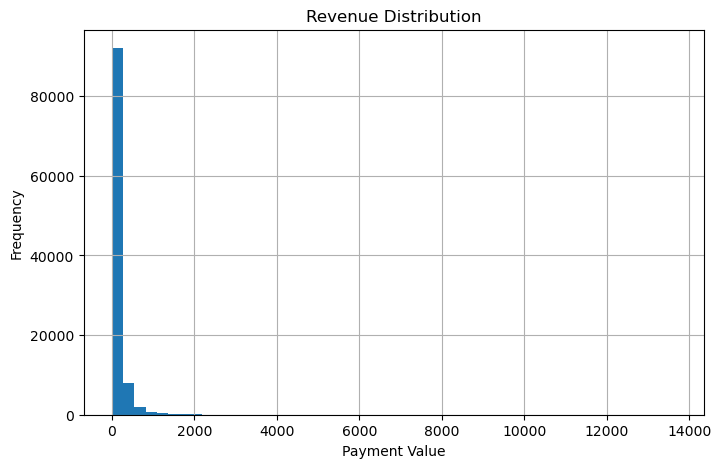

In [45]:
## Revenue Distribution

plt.figure(figsize = (8,5))
df['payment_value'].hist(
    bins = 50
)
plt.title('Revenue Distribution')
plt.xlabel('Payment Value')
plt.ylabel('Frequency')
plt.show()

In [46]:
df['payment_value'].sum()

np.float64(16008872.12)

In [47]:
state_revenue.head(10)

customer_state
SP    5998226.96
RJ    2144379.69
MG    1872257.26
RS     890898.54
PR     811156.38
SC     623086.43
BA     616645.82
DF     355141.08
GO     350092.31
ES     325967.55
Name: payment_value, dtype: float64

In [48]:
top_customers.head(10)

customer_unique_id
0a0a92112bd4c708ca5fde585afaa872    13664.08
46450c74a0d8c5ca9395da1daac6c120     9553.02
da122df9eeddfedc1dc1f5349a1a690c     7571.63
763c8b1c9c68a0229c42c9fc6f662b93     7274.88
dc4802a71eae9be1dd28f5d788ceb526     6929.31
459bef486812aa25204be022145caa62     6922.21
ff4159b92c40ebe40454e3e6a7c35ed6     6726.66
4007669dec559734d6f53e029e360987     6081.54
5d0a2980b292d049061542014e8960bf     4809.44
eebb5dda148d3893cdaf5b5ca3040ccb     4764.34
Name: payment_value, dtype: float64

In [49]:
df['order_purchase_timestamp']  = pd.to_datetime(df['order_purchase_timestamp'])

In [50]:
df['Year'] = df['order_purchase_timestamp'].dt.year

In [51]:
df['Month'] = df['order_purchase_timestamp'].dt.month_name()

In [52]:
df['Quarter'] = df['order_purchase_timestamp'].dt.quarter

In [53]:
df['Day'] = df['order_purchase_timestamp'].dt.day_name()

In [54]:
df[['order_purchase_timestamp','Year','Month','Quarter','Day']].head()

,order_purchase_timestamp,Year,Month,Quarter,Day
0,2017-10-02 10:56:33,2017,October,4,Monday
1,2017-10-02 10:56:33,2017,October,4,Monday
2,2017-10-02 10:56:33,2017,October,4,Monday
3,2018-07-24 20:41:37,2018,July,3,Tuesday
4,2018-08-08 08:38:49,2018,August,3,Wednesday


In [55]:
## Summary Statistics

df.describe()

,order_purchase_timestamp,payment_sequential,payment_installments,payment_value,customer_zip_code_prefix,Year,Quarter
count,103887,103886.000000,103886.000000,103886.000000,103887.000000,103887.000000,103887.000000
mean,2017-12-29 21:42:16.455099904,1.092679,2.853349,154.100380,35072.353490,2017.535851,2.355559
min,2016-09-04 21:15:19,1.000000,0.000000,0.000000,1003.000000,2016.000000,1.000000
25%,2017-09-10 08:02:59.500000,1.000000,1.000000,56.790000,11367.500000,2017.000000,1.000000
50%,2018-01-17 14:07:07,1.000000,1.000000,100.000000,24360.000000,2018.000000,2.000000
75%,2018-05-03 18:35:46.500000,1.000000,4.000000,171.837500,58418.000000,2018.000000,3.000000
max,2018-10-17 17:30:18,29.000000,24.000000,13664.080000,99990.000000,2018.000000,4.000000
std,NaN,0.706584,2.687051,217.494064,29743.416343,0.505369,1.060944


In [56]:
## Payment Value Statistics

df['payment_value'].describe()

count    103886.000000
mean        154.100380
std         217.494064
min           0.000000
25%          56.790000
50%         100.000000
75%         171.837500
max       13664.080000
Name: payment_value, dtype: float64

In [57]:
## Median payment

df['payment_value'].std()

217.49406386472862

In [58]:
## Standard Deviation

df['payment_value'].std()

217.49406386472862

In [60]:
## Variance

df['payment_value'].var()

47303.667816394656

In [61]:
## Revenue by Month

monthly_sales=(
    df.groupby('Month')['payment_value'].sum().sort_values(ascending=False)
)
monthly_sales

Month
May          1746900.97
August       1696821.64
July         1658923.67
March        1609515.72
April        1578573.51
June         1535156.88
February     1284371.35
January      1253492.22
November     1194882.80
December      878421.10
October       839358.03
September     732454.23
Name: payment_value, dtype: float64

In [62]:
## order Status Count

df['order_status'].value_counts()

order_status
delivered      100757
shipped          1166
canceled          664
unavailable       649
invoiced          325
processing        319
created             5
approved            2
Name: count, dtype: int64

In [63]:
## Revenue by Order Status

df.groupby('order_status')['payment_value'].sum()

order_status
approved            241.08
canceled         143255.60
created             688.10
delivered      15422461.77
invoiced          69137.99
processing        69394.11
shipped          177213.96
unavailable      126479.51
Name: payment_value, dtype: float64

### Customer Segmentation & Business KPIs

In [64]:
## Total Orders

total_orders = df['order_id'].nunique()
print("Total Orders:",total_orders)

Total Orders: 99441


In [66]:
## Total Customers

total_customers = df['customer_unique_id'].nunique()
print("Total Customers:",total_customers)

Total Customers: 96096


In [68]:
## Average Order Value (AOV)

average_order_value = df.groupby('order_id')['payment_value'].sum().mean()
print("Average Order Value:",round(average_order_value,2))

Average Order Value: 160.99


In [69]:
## Average Revenue Customer

avg_customer_revenue=(
    df.groupby('customer_unique_id')['payment_value'].sum().mean()
)
print(round(avg_customer_revenue,2))

166.59


In [78]:
## Top 10 States by Orders

top_states = (
    df.groupby('customer_state')['order_id'].nunique().sort_values(ascending=False)
)
top_states.head(10)

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: order_id, dtype: int64

In [79]:
category_translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [80]:
## Top Product Categories

## First Merge the translation table

products = products.merge(
    category_translation,
    on = 'product_category_name',
    how = 'left'
)

In [81]:
products.columns

Index(['product_id', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'product_category_name_english'],
      dtype='object')

In [87]:
## Then merge with your main dataframe

df = df.merge(
    products[['product_id','product_category_name_english']],on = 'product_id',
    how = 'left'
)

In [86]:
'product_id' in df.columns

True

In [88]:
print(df.columns.tolist())

['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'Year', 'Month', 'Quarter', 'Day', 'product_id_x', 'product_id_y', 'product_id', 'product_category_name_english']


In [93]:
print(df.columns.tolist())

['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'Year', 'Month', 'Quarter', 'Day', 'product_id', 'product_category_name_english']


In [94]:
print(df.filter(like='product').columns.tolist())

['product_id', 'product_category_name_english']


In [95]:
print(df.shape)

(372852, 22)


In [96]:
top_categories = (
    df.groupby('product_category_name_english')['payment_value']
      .sum()
      .sort_values(ascending=False)
)

top_categories.head(10)

product_category_name_english
computers_accessories    31940388.82
auto                     20487547.31
furniture_decor          16157972.39
office_furniture         12526326.54
garden_tools             11432887.96
housewares               11311276.33
bed_bath_table            9979239.54
fixed_telephony           8114225.79
health_beauty             6675061.79
watches_gifts             5629529.07
Name: payment_value, dtype: float64

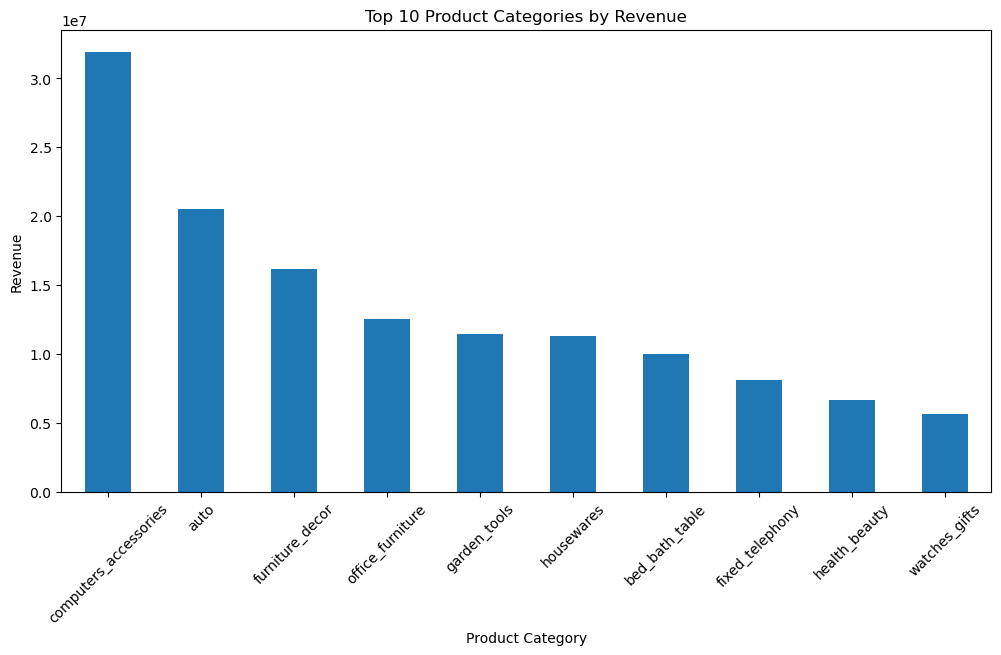

In [97]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

top_categories.head(10).plot(kind='bar')

plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Product Category")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

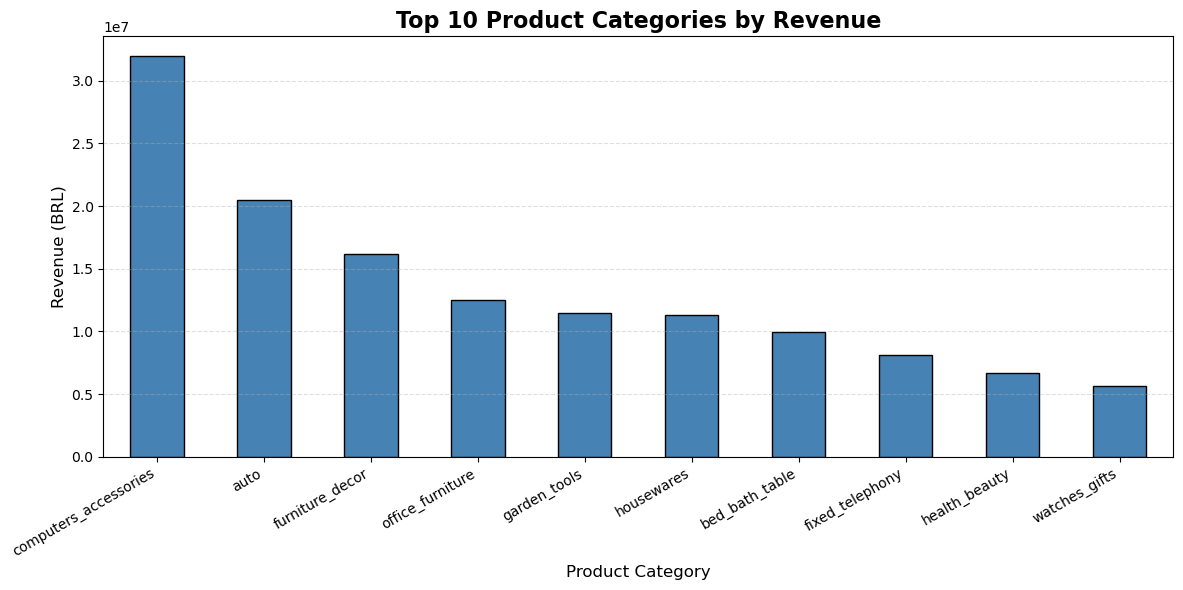

In [98]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

top_categories.head(10).plot(
    kind='bar',
    color='steelblue',
    edgecolor='black'
)

plt.title("Top 10 Product Categories by Revenue", fontsize=16, fontweight='bold')
plt.xlabel("Product Category", fontsize=12)
plt.ylabel("Revenue (BRL)", fontsize=12)

plt.xticks(rotation=30, ha='right')

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()

plt.show()

In [100]:
## Total Revenue

total_revenue = df['payment_value'].sum()

print(f"Total Revenue: {total_revenue:,.2f}")

Total Revenue: 176,149,051.72


In [101]:
## Revenue per Customer

customer_revenue = (
    df.groupby('customer_unique_id')['payment_value']
      .sum()
      .sort_values(ascending=False)
)

customer_revenue.head(10)

customer_unique_id
698e1cf81d01a3d389d96145f7fa6df8    18102400.00
c402f431464c72e27330a67f7b94d4fb    17619200.00
0a0a92112bd4c708ca5fde585afaa872     6996008.96
0f5ac8d5c31de21d2f25e24be15bbffb     4145186.34
ef8d54b3797ea4db1d63f0ced6a906e9     3018600.00
31e412b9fb766b6794724ed17a41dfa6     2782470.88
eae0a83d752b1dd32697e0e7b4221656     2697605.49
11f97da02237a49c8e783dfda6f50e8e     2642625.00
9eca552063680b7cd2ed0e8aea002b21     2561310.72
3d47f4368ccc8e1bb4c4a12dbda7111b     2234660.00
Name: payment_value, dtype: float64

In [103]:
## Repeat Customers

repeat_customers = (
    df.groupby('customer_unique_id')['order_id']
      .nunique()
)

repeat_customers.head()

customer_unique_id
0000366f3b9a7992bf8c76cfdf3221e2    1
0000b849f77a49e4a4ce2b2a4ca5be3f    1
0000f46a3911fa3c0805444483337064    1
0000f6ccb0745a6a4b88665a16c9f078    1
0004aac84e0df4da2b147fca70cf8255    1
Name: order_id, dtype: int64

In [106]:
## count customers with more than one order:

repeat_count = (repeat_customers > 1).sum()

print("Repeat Customers:", repeat_count)

Repeat Customers: 2997


In [108]:
## Customer Segmentation
## Create Three Customer Segments

customer_value = (
    df.groupby('customer_unique_id')['payment_value'].sum()
)

In [109]:
## Create Segments

customer_segment = pd.qcut(
    customer_value,
    q = 3,
    labels = [
        'low value',
        'medium value',
        'high value'
    ]
)
customer_segment.value_counts()

payment_value
low value       32046
high value      32032
medium value    32018
Name: count, dtype: int64

In [110]:
## Monthly Revenue Trend

monthly_revenue =(
    df.groupby(['Year','Month'])['payment_value'].sum().reset_index()
)
monthly_revenue.head()

,Year,Month,payment_value
0,2016,December,19.62
1,2016,October,444605.13
2,2016,September,1205.85
3,2017,April,2167700.83
4,2017,August,21239112.73


In [115]:
## Revenue by Day of Week

day_revenue = (
    df.groupby('Day')['payment_value']
)
day_revenue.head()

0      18.12
1       2.00
2      18.59
3     141.46
4     179.12
5      72.20
6      28.62
7     175.26
8      65.95
9      75.16
10     35.95
11    161.42
12      8.34
13    259.06
21    114.13
22     50.13
23     32.70
24     54.36
25    146.45
29     62.15
32    118.86
34     17.28
47    192.68
48     63.34
52    100.25
53    188.41
55     66.79
57    508.17
59    154.19
60    356.12
61     95.67
65     54.82
67     52.24
68    130.56
79    386.33
Name: payment_value, dtype: float64

In [116]:
## Business KPIs

kpi = pd.DataFrame({

'Metric':[
'Total Revenue',
'Total Orders',
'Total Customers',
'Average Order Value'
],

'Value':[

df['payment_value'].sum(),

df['order_id'].nunique(),

df['customer_unique_id'].nunique(),

round(average_order_value,2)

]

})

kpi

,Metric,Value
0,Total Revenue,1.761491e+08
1,Total Orders,9.944100e+04
2,Total Customers,9.609600e+04
3,Average Order Value,1.609900e+02


In [117]:
print(df.shape)

print(df['order_id'].nunique())

print(df['payment_value'].sum())

(372852, 22)
99441
176149051.72000006


In [118]:
df_orders = (
    orders
    .merge(payments, on='order_id', how='left')
    .merge(customers, on='customer_id', how='left')
)

In [119]:
df_orders['order_purchase_timestamp'] = pd.to_datetime(df_orders['order_purchase_timestamp'])

df_orders['Year'] = df_orders['order_purchase_timestamp'].dt.year
df_orders['Month'] = df_orders['order_purchase_timestamp'].dt.month_name()
df_orders['Quarter'] = df_orders['order_purchase_timestamp'].dt.quarter
df_orders['Day'] = df_orders['order_purchase_timestamp'].dt.day_name()

In [120]:
df['payment_value'].describe()

count    372825.000000
mean        472.471137
std         772.085710
min           0.000000
25%         114.490000
50%         215.990000
75%         494.100000
max       13664.080000
Name: payment_value, dtype: float64

In [122]:
Q1 = df['payment_value'].quantile(0.25)
Q3 = df['payment_value'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

outliers = df[
    (df['payment_value'] < lower_limit) |
    (df['payment_value'] > upper_limit)
]

print("Number of Outliers:", len(outliers))

Q1: 114.49
Q3: 494.1
IQR: 379.61
Lower Limit: -454.92499999999995
Upper Limit: 1063.5149999999999
Number of Outliers: 43473


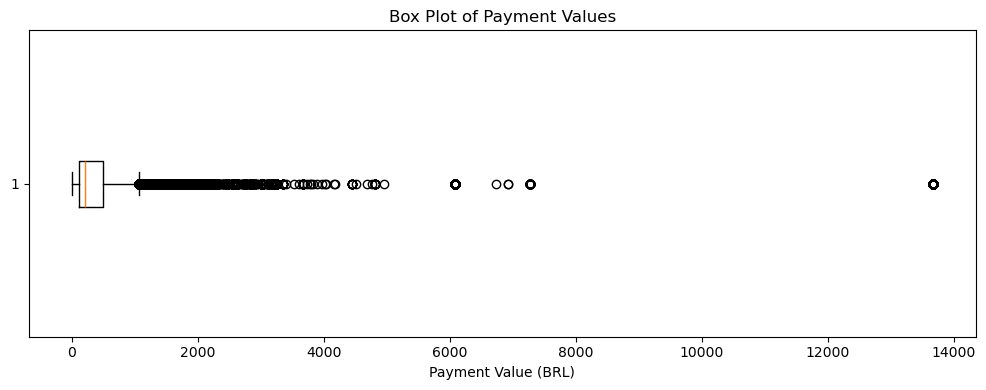

In [125]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.boxplot(df['payment_value'].dropna(), vert=False)

plt.title("Box Plot of Payment Values")
plt.xlabel("Payment Value (BRL)")

plt.tight_layout()
plt.show()

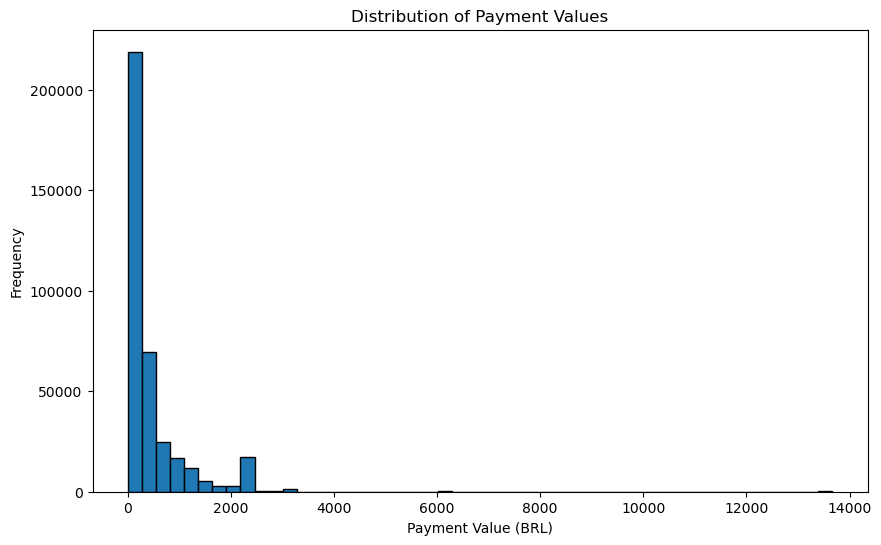

In [126]:
plt.figure(figsize=(10,6))

plt.hist(
    df['payment_value'],
    bins=50,
    edgecolor='black'
)

plt.title("Distribution of Payment Values")
plt.xlabel("Payment Value (BRL)")
plt.ylabel("Frequency")

plt.show()

In [127]:
print(df.select_dtypes(include='number').columns.tolist())

['payment_sequential', 'payment_installments', 'payment_value', 'customer_zip_code_prefix', 'Year', 'Quarter']


In [128]:
correlation = df.select_dtypes(include='number').corr()

correlation

,payment_sequential,payment_installments,payment_value,customer_zip_code_prefix,Year,Quarter
payment_sequential,1.000000,-0.074731,-0.058114,-0.018487,-0.031084,0.006696
payment_installments,-0.074731,1.000000,0.085146,0.086094,-0.050367,0.029642
payment_value,-0.058114,0.085146,1.000000,0.074440,-0.026608,0.001051
customer_zip_code_prefix,-0.018487,0.086094,0.074440,1.000000,-0.050070,0.007471
Year,-0.031084,-0.050367,-0.026608,-0.050070,1.000000,-0.582513
Quarter,0.006696,0.029642,0.001051,0.007471,-0.582513,1.000000


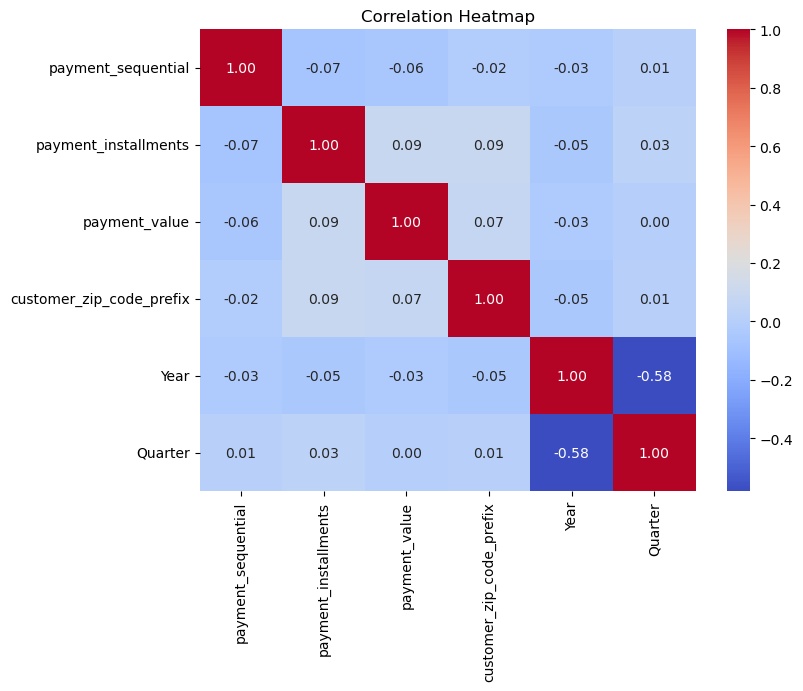

In [129]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [132]:
df.to_csv("ecommerce_sales_final.csv", index=False)

In [133]:
import os
print(os.getcwd())

D:\Ecommerce_Customer_Sales_Analytics
